In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('Cardiotocographic.csv')
df.head()
df.info()
df.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


<bound method NDFrame.describe of               LB        AC        FM        UC        DL   DS   DP  ASTV  \
0     120.000000  0.000000  0.000000  0.000000  0.000000  0.0  0.0  73.0   
1     132.000000  0.006380  0.000000  0.006380  0.003190  0.0  0.0  17.0   
2     133.000000  0.003322  0.000000  0.008306  0.003322  0.0  0.0  16.0   
3     134.000000  0.002561  0.000000  0.007742  0.002561  0.0  0.0  16.0   
4     131.948232  0.006515  0.000000  0.008143  0.000000  0.0  0.0  16.0   
...          ...       ...       ...       ...       ...  ...  ...   ...   
2121  140.000000  0.000000  0.961268  0.007426  0.000000  0.0  0.0  79.0   
2122  140.000000  0.000775  0.000000  0.006979  0.000000  0.0  0.0  78.0   
2123  140.000000  0.000980  0.000000  0.006863  0.000000  0.0  0.0  79.0   
2124  140.000000  0.000679  0.000000  0.006110  0.000000  0.0  0.0  78.0   
2125  142.000000  0.001616 -0.000188  0.008078  0.000000  0.0  0.0  74.0   

      MSTV       ALTV  MLTV  Width  Tendency       NS

In [21]:
df = df.fillna(df.mean())

In [22]:
df['NSP'] = df['NSP'].astype(int)

In [23]:
plt.figure(figsize=(12, 4))

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

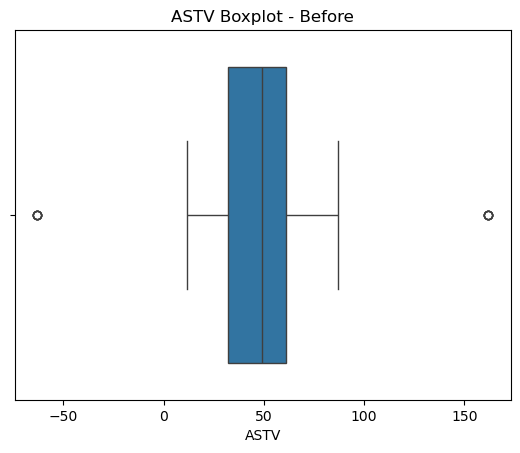

In [24]:
sns.boxplot(x=df['ASTV'])
plt.title('ASTV Boxplot - Before')
plt.show()

In [25]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

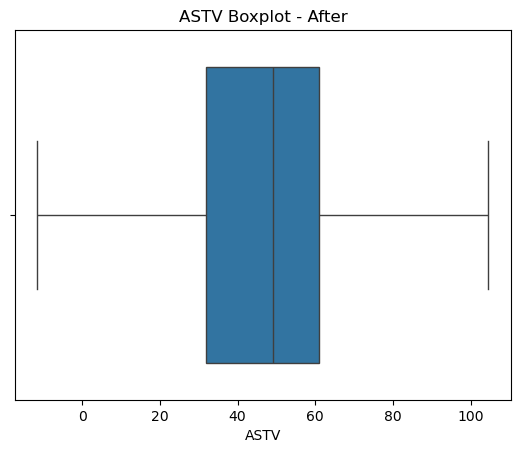

In [26]:
sns.boxplot(x=df['ASTV'])
plt.title('ASTV Boxplot - After')
plt.show()

I loaded the data, filled missing values with column averages so no rows got dropped. Then I checked outliers with a boxplot. Saw dots outside whiskers, so I used the IQR method to cap them. Made another boxplot after that outliers handled.

In [27]:
stats_df = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Standard Deviation': df.std(),
    'IQR': df.quantile(0.75) - df.quantile(0.25)
})

In [28]:
stats_df

,Mean,Median,Standard Deviation,IQR
LB,133.293725,133.000000,9.930227,14.000000
AC,0.003147,0.001668,0.003826,0.005606
FM,0.001568,0.000000,0.002485,0.002567
UC,0.004362,0.004484,0.003001,0.004685
DL,0.001770,0.000000,0.002668,0.003289
DS,0.000000,0.000000,0.000000,0.000000
DP,0.000000,0.000000,0.000000,0.000000
ASTV,46.981873,49.000000,17.612745,29.000000
MSTV,1.304644,1.200000,0.781091,1.000000
ALTV,6.691678,0.000000,10.378400,11.000000


Looking at the summary table, ASTV has a big standard deviation, so patients vary a lot. LB (baseline fetal heart rate) is pretty steady though, with a median around 133 bpm.

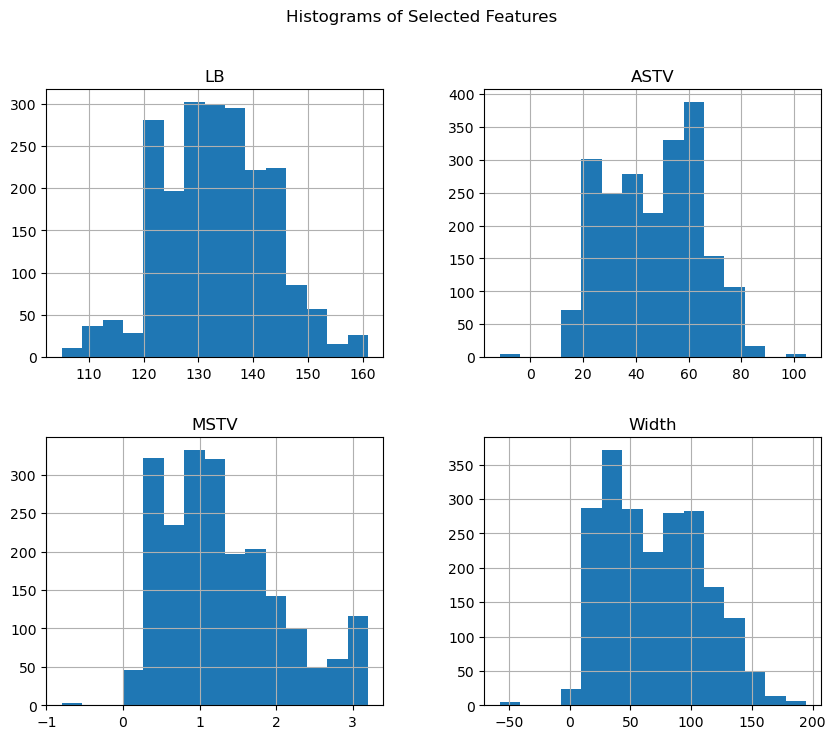

In [29]:
df[['LB', 'ASTV', 'MSTV', 'Width']].hist(figsize=(10, 8), bins=15)
plt.suptitle('Histograms of Selected Features')
plt.show()

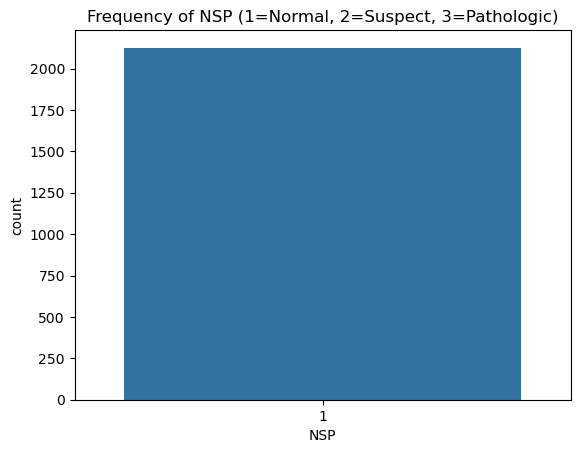

In [30]:
sns.countplot(x='NSP', data=df)
plt.title('Frequency of NSP (1=Normal, 2=Suspect, 3=Pathologic)')
plt.show()

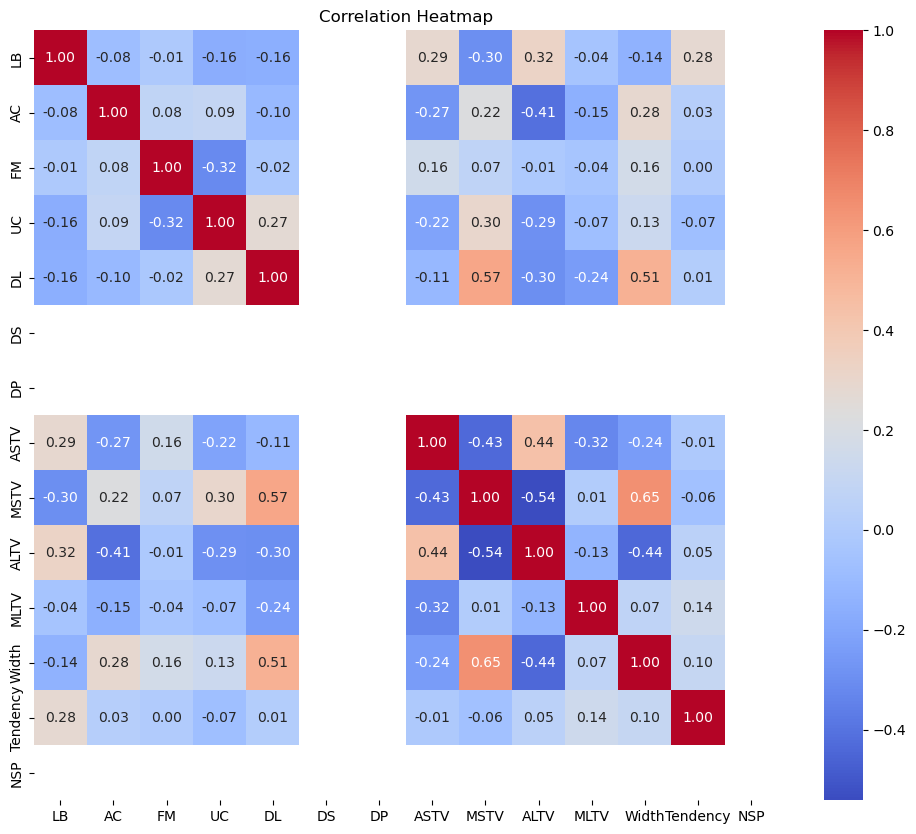

In [31]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

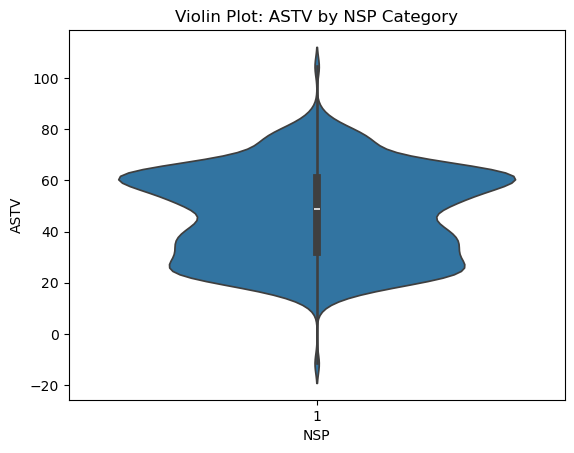

In [32]:
sns.violinplot(x='NSP', y='ASTV', data=df)
plt.title('Violin Plot: ASTV by NSP Category')
plt.show()

From the heatmap and violin plot:
ASTV goes up ::- NSP more likely “Suspect” or “Pathologic.”
AC goes down :- NSP worse.